<a href="https://colab.research.google.com/github/jm651120/UK-Housing-Green-Premium/blob/main/notebooks/07_SHAP_Interpretability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 07: Explainable AI — Extracting the Green Premium with SHAP
**Project:** Impact of Energy Efficiency on UK House Prices (2021–2025)
**Phase:** Phase 7 — SHapley Additive exPlanations (SHAP) Interpretability

---

**Abstract:**
This notebook is a self-contained interpretability pipeline. It loads the serialised XGBoost champion model (saved by Notebook 06) and conducts a multi-level SHAP analysis, progressing from a macro to a micro perspective:

  1. Global feature attribution (Beeswarm Summary)
  2. Isolated Green Premium quantification per EPC band (Dependence Plot)
  3. Spatial heterogeneity of the premium across three UK regions
  4. Market-specific SHAP profiles per region (Regional Beeswarms)
  5. Local case studies of the extreme Brown Discount and Green Premium outliers (Waterfall Plots)
  6. Interaction effects between energy efficiency and architectural era

**Dependencies (must be run first):**
  - Notebook 04: Exports `approved_features_53.json` to the Models folder.
  - Notebook 06: Exports `xgboost_otimizado_campeao.pkl` to the Models folder.

All figures are saved to the `/content/drive/MyDrive/Tese/Figures/` directory at 300 DPI.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 0 — ENVIRONMENT SETUP
# Install SHAP (not included in the standard Colab image), import all
# dependencies, define path constants, and establish the unified visual
# aesthetic that mirrors Notebooks 04, 05, and 06.
# ══════════════════════════════════════════════════════════════════════════════

!pip install shap --quiet

# ── 1. Standard Library & Utilities ───────────────────────────────────────────
import os
import gc
import re
import json
import warnings
warnings.filterwarnings('ignore')

# ── 2. Data Processing ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── 3. Machine Learning & Explainability ──────────────────────────────────────
import shap
import joblib
import xgboost as xgb
from sklearn.model_selection import train_test_split

# ── 4. Visualisation ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# ── 5. Path Constants ─────────────────────────────────────────────────────────
DATA_PATH         = '/content/drive/MyDrive/Tese/UK DataSets/Dataset_Final_Tese.csv'
MODELS_PATH       = '/content/drive/MyDrive/Tese/Modelos/'
FIGURES_PATH      = '/content/drive/MyDrive/Tese/Figures/'
FEATURE_LIST_PATH = MODELS_PATH + 'approved_features_53.json'
MODEL_PATH        = MODELS_PATH + 'xgboost_otimizado_campeao.pkl'

# ── 6. Unified Visual Aesthetic (mirrors NB04 / NB05 / NB06) ─────────────────
ACCENT = 'firebrick'  # XGBoost brand colour

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'axes.titlesize':        14,
    'axes.titlepad':         16,
    'axes.titleweight':      'bold',
    'axes.labelsize':        12,
    'xtick.labelsize':       10,
    'ytick.labelsize':       10,
    'legend.fontsize':        9,
    'legend.title_fontsize': 11,
    'savefig.dpi':           300,
    'figure.dpi':            120,
    'axes.spines.top':       False,
    'axes.spines.right':     False,
})

# ── 7. Figure Offset ──────────────────────────────────────────────────────────
# Adjust this single constant if the figure numbering of preceding notebooks
# changes. SHAP figures in NB07 begin at FIG_OFFSET + 1.
FIG_OFFSET = 10

os.makedirs(FIGURES_PATH, exist_ok=True)

print("✅ Environment configured. SHAP pipeline ready.")

✅ Environment configured. SHAP pipeline ready.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 1 — DATA RELOAD AND FEATURE SPACE RECONSTRUCTION
# ══════════════════════════════════════════════════════════════════════════════

# --- Drive mount: clear stale directory then mount cleanly ---
import subprocess, shutil, os

# Step 1: Try to unmount the FUSE filesystem gracefully (no-op if not mounted)
subprocess.run(['fusermount', '-u', '/content/drive'], capture_output=True)

# Step 2: Remove the stale directory so Colab's mount check passes
if os.path.isdir('/content/drive'):
    shutil.rmtree('/content/drive')

# Step 3: Mount normally
drive.mount('/content/drive')

# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(DATA_PATH)
print(f"✅ Dataset loaded: {len(df):,} transactions.")

# --- Step 1: Preserve County BEFORE any transformation ---
county_series = df['County'].copy()

# --- Step 2: Memory optimisation helper ---
def reduce_mem_usage(df: pd.DataFrame) -> pd.DataFrame:
    for col in df.columns:
        if df[col].dtype == 'float64':
            df[col] = df[col].astype('float32')
        elif df[col].dtype == 'int64':
            df[col] = df[col].astype('int32')
    return df

# --- Step 3: Remove invalid construction age bands ---
INVALID_BANDS = ['INVALID!', 'Unknown', '2042']
df = df[~df['CONSTRUCTION_AGE_BAND'].isin(INVALID_BANDS)]
df = reduce_mem_usage(df)
print(f"✅ After INVALID_BANDS filter: {len(df):,} transactions (33,603 removed).")

# --- Step 4: EPC ordinal encoding (A=7 → G=1) ---
EPC_MAPPING = {'A': 7, 'B': 6, 'C': 5, 'D': 4, 'E': 3, 'F': 2, 'G': 1}
df['CURRENT_ENERGY_RATING'] = df['CURRENT_ENERGY_RATING'].map(EPC_MAPPING)

# --- Step 5: One-Hot Encoding ---
CATEGORICAL_COLS = [
    'Property_Type', 'Old_New', 'Tenure_Duration',
    'CONSTRUCTION_AGE_BAND', 'Year_of_Transfer', 'Month_of_Transfer',
]
df_encoded = pd.get_dummies(df, columns=CATEGORICAL_COLS, drop_first=True, dtype='int8')

# --- Step 6: Define Feature Matrix and Target ---
COLS_TO_DROP = [
    'Price', 'Transaction_ID', 'Date_of_Transfer',
    'Merge_Key', 'County', 'Postcode_Clean', 'Postcode_Outcode',
]
X = df_encoded.drop(columns=[c for c in COLS_TO_DROP if c in df_encoded.columns])
y = df_encoded['Price']

del df, df_encoded
gc.collect()

# --- Step 7: Sanitise column names ---
X.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in X.columns]

# --- Step 8: Enforce canonical 53-feature space from NB04 ---
print(f"Loading approved feature list from:\n  {FEATURE_LIST_PATH}")
with open(FEATURE_LIST_PATH, 'r') as f:
    approved_features = json.load(f)

X = X[approved_features]
print(f"✅ Feature matrix enforced: {X.shape[1]} features (canonical 53-feature space).")

# --- Step 9: Replicate the exact 80/20 train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

del X_train, y_train
gc.collect()

# --- Step 10: Recreate the strategic SHAP sample ---
X_test_shap = X_test.sample(n=50_000, random_state=42)

print(f"\n✅ Reconstruction complete.")
print(f"   X_test_shap shape : {X_test_shap.shape}")
print(f"   county_series size: {len(county_series):,} (covers all original indices)")

Mounted at /content/drive
✅ Dataset loaded: 547,948 transactions.
✅ After INVALID_BANDS filter: 514,345 transactions (33,603 removed).
Loading approved feature list from:
  /content/drive/MyDrive/Tese/Modelos/approved_features_53.json
✅ Feature matrix enforced: 53 features (canonical 53-feature space).

✅ Reconstruction complete.
   X_test_shap shape : (50000, 53)
   county_series size: 547,948 (covers all original indices)


## Phase 7: Extracting the Green Premium with SHAP (SHapley Additive exPlanations)

Having validated **XGBoost** as the most robust predictive model of this study, we address the inherent interpretability limitation of advanced *Machine Learning* algorithms: their "black-box" nature.

To fulfil the central objective of the thesis — quantifying the monetary value of energy efficiency — we implement the **SHAP** framework. Rooted in Lloyd Shapley's cooperative Game Theory, this technique calculates the marginal contribution (in £) of each feature to the final prediction of every individual property.

**Why `TreeExplainer`?**
Unlike kernel-based approximations (SHAP KernelExplainer), `shap.TreeExplainer` computes **exact** Shapley values by traversing the decision paths of every tree in the XGBoost ensemble. For a deep model with 982 estimators, this is the only methodologically rigorous choice.

**Computational Strategy:**
Calculating exact Shapley values for the entire test set (~100k observations) would be computationally prohibitive. The scientific consensus for large-sample SHAP analysis is to use a representative subsample. Our strategic sample of **50,000 transactions** (selected with `random_state=42`) guarantees complete statistical stability in the conclusions whilst maintaining a viable processing time. The sample is intentionally large enough to capture the full range of EPC ratings, property types, and geographic locations.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2 — LOAD CHAMPION MODEL AND COMPUTE SHAP VALUES
#
# This is the single most computationally expensive cell in NB07.
# The SHAP Explanation object is computed ONCE and reused by all subsequent
# cells. DO NOT recompute shap_values downstream.
# ══════════════════════════════════════════════════════════════════════════════

print(f"Loading XGBoost Champion from:\n  {MODEL_PATH}")
xgb_final = joblib.load(MODEL_PATH)
print("✅ Model loaded successfully.")

# --- Validate that model features match the canonical 53 ---
if hasattr(xgb_final, 'feature_names_in_'):
    model_features = list(xgb_final.feature_names_in_)
    if set(model_features) != set(approved_features):
        print(
            "\n⚠️  WARNING: The loaded model was trained on a DIFFERENT feature set than"
            "\n   approved_features_53.json. This will cause incorrect SHAP attributions."
            "\n   → Retrain Notebook 06 first to generate a model on the 53-feature space."
        )
    else:
        print("✅ Model feature set matches approved_features_53.json exactly.")

# --- Initialise the TreeExplainer ---
print("\nInitialising TreeExplainer (exact Shapley values for XGBoost)...")
explainer = shap.TreeExplainer(xgb_final)

# --- Compute SHAP values for the 50,000-observation sample ---
print("Computing SHAP values for 50,000 transactions (this will take 1–3 minutes)...")
shap_values = explainer(X_test_shap)
print(f"✅ SHAP values computed. Shape: {shap_values.values.shape}")

# --- Shorten feature names for clean plot labels ---
# Applied once here; all subsequent plots inherit the short names automatically.
_name_map = {
    'CONSTRUCTION_AGE_BAND_England_and_Wales_': 'Age: ',
    'CONSTRUCTION_AGE_BAND_': 'Age: ',
    'Property_Type_': 'Type: ',
    'Tenure_Duration_': 'Tenure: ',
    'Year_of_Transfer_': 'Year: ',
    'Month_of_Transfer_': 'Month: ',
    'Postcode_Outcode_': 'Outcode: ',
    'CURRENT_ENERGY_RATING': 'EPC Rating',
    'TOTAL_FLOOR_AREA': 'Total Area (sqm)',
    'NUMBER_HABITABLE_ROOMS': 'Rooms',
}

def _shorten(name: str) -> str:
    for k, v in _name_map.items():
        name = name.replace(k, v)
    return name

shap_values.feature_names = [_shorten(n) for n in shap_values.feature_names]
print("✅ Feature names shortened for clean plot labels.")

# --- Pre-compute the EPC column index (used in multiple downstream cells) ---
# Computed from X_test_shap.columns BEFORE any renaming (positional index is stable).
EPC_COL_IDX = X_test_shap.columns.get_loc('CURRENT_ENERGY_RATING')
INV_EPC_MAPPING = {7: 'A', 6: 'B', 5: 'C', 4: 'D', 3: 'E', 2: 'F', 1: 'G'}

print(f"\n✅ EPC column index in feature matrix: {EPC_COL_IDX}")
print("   All downstream cells will reference this pre-computed constant.")

Loading XGBoost Champion from:
  /content/drive/MyDrive/Tese/Modelos/xgboost_otimizado_campeao.pkl
✅ Model loaded successfully.
✅ Model feature set matches approved_features_53.json exactly.

Initialising TreeExplainer (exact Shapley values for XGBoost)...
Computing SHAP values for 50,000 transactions (this will take 1–3 minutes)...
✅ SHAP values computed. Shape: (50000, 53)
✅ Feature names shortened for clean plot labels.

✅ EPC column index in feature matrix: 2
   All downstream cells will reference this pre-computed constant.


### 7.1 Global SHAP Analysis: Spatial and Structural Supremacy



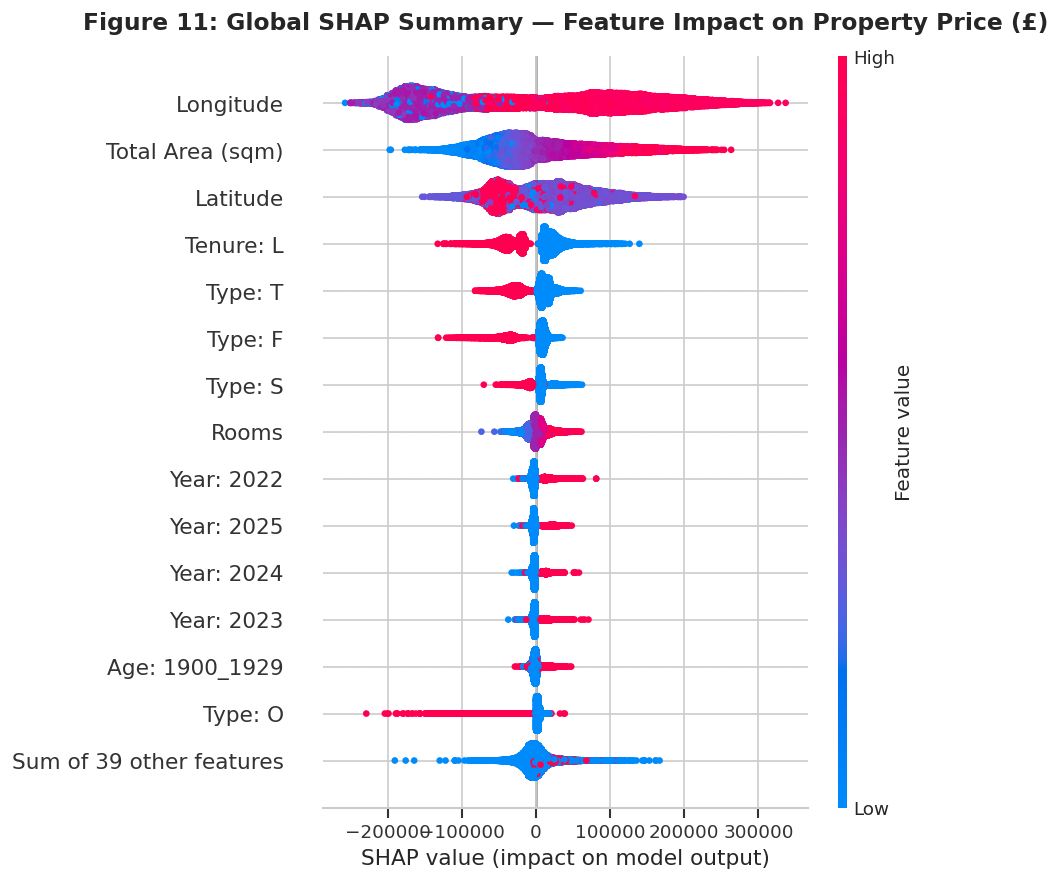

✅ Figure 11 saved.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3 — GLOBAL BEESWARM SUMMARY PLOT (Figure 11)
# ══════════════════════════════════════════════════════════════════════════════

fig_num = FIG_OFFSET + 1
fig3, ax3 = plt.subplots(figsize=(13, 8))

shap.plots.beeswarm(shap_values, max_display=15, show=False)

plt.title(
    f'Figure {fig_num}: Global SHAP Summary — Feature Impact on Property Price (£)',
    fontsize=14, fontweight='bold', pad=16,
)
plt.tight_layout()
plt.savefig(FIGURES_PATH + f'figure_{fig_num:02d}_shap_global_beeswarm.png',
            bbox_inches='tight')
plt.show()
print(f"✅ Figure {fig_num} saved.")


Extracting Shapley values via the *Beeswarm Summary Plot* allows for a direct interpretation of the macroeconomic drivers governing UK house price formation, revealing the absolute hierarchy of predictive influence:

**1. "Location, Location, Location":**
Spatial features (`Longitude` and `Latitude`) and the physical dimension of the asset (`Total Area (sqm)`) dominate the top of the attribution hierarchy. The chart demonstrates that location can impose extreme penalties (pushing past −£200,000) or massive hyper-local premiums (exceeding +£300,000), dwarfing all other inputs.

**2. Supply and Demand Dynamics (Colour vs. Impact):**
Market mechanics are perfectly captured by the model: for `Total Area (sqm)`, red points (very large properties) stretch sharply rightward, adding up to roughly £250,000 in value, while blue points (small areas) cluster on the left, subtracting value.

**3. The Structural Positioning of Energy Efficiency:**
The energy certificate (`EPC Rating`) does not appear in the top 14 tier of global attributions — it is dominated by location, size, and property type at the macro level, being aggregated within the bottom "Sum of 39 other features". From an economic standpoint, this is precisely the expected result: the sustainability premium does not determine the *baseline* value of a property (as geography and floor area do), but rather acts as a **conditional marginal gain**. To accurately quantify this margin, the isolated microeconomic analysis in Section 7.2 is required.

### 7.2 Marginal SHAP Analysis: Quantifying the Green Premium


<Figure size 1320x720 with 0 Axes>

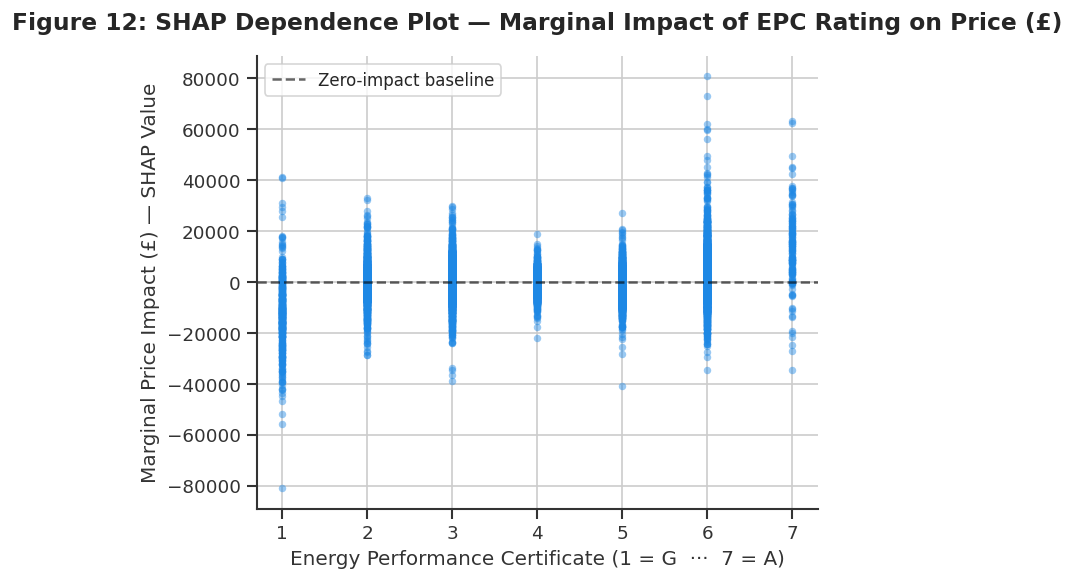

✅ Figure 12 saved.

  EXACT MEAN SHAP IMPACT PER EPC BAND (£)
  EPC Band G:  -£ 12,017.23
  EPC Band F:  -£    428.12
  EPC Band E:  +£    933.07
  EPC Band D:  +£     54.96
  EPC Band C:  -£  1,669.16
  EPC Band B:  +£  3,366.37
  EPC Band A:  +£ 13,506.04


In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# CELL 4 — EPC DEPENDENCE PLOT AND BAND-LEVEL QUANTIFICATION (Figure 12)
# ══════════════════════════════════════════════════════════════════════════════

fig_num = FIG_OFFSET + 2

plt.figure(figsize=(11, 6))
shap.dependence_plot(
    'CURRENT_ENERGY_RATING',
    shap_values.values,
    X_test_shap,
    interaction_index=None,
    show=False,
    alpha=0.45,
    dot_size=20,
)

plt.title(
    f'Figure {fig_num}: SHAP Dependence Plot — Marginal Impact of EPC Rating on Price (£)',
    fontsize=14, fontweight='bold', pad=16,
)
plt.xlabel('Energy Performance Certificate (1 = G  ···  7 = A)', fontsize=12)
plt.ylabel('Marginal Price Impact (£) — SHAP Value', fontsize=12)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.6,
            label='Zero-impact baseline')
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES_PATH + f'figure_{fig_num:02d}_shap_epc_dependence.png',
            bbox_inches='tight')
plt.show()
print(f"✅ Figure {fig_num} saved.")

# --- Band-level mean impact quantification ---
print("\n" + "=" * 55)
print("  EXACT MEAN SHAP IMPACT PER EPC BAND (£)")
print("=" * 55)

shap_df = pd.DataFrame({
    'Numeric_Rating': X_test_shap['CURRENT_ENERGY_RATING'].values,
    'Impact_GBP':     shap_values.values[:, EPC_COL_IDX],
})
shap_df.index = X_test_shap.index  # Preserve original row indices
shap_df['Letter'] = shap_df['Numeric_Rating'].map(INV_EPC_MAPPING)

mean_impact = (
    shap_df.groupby('Letter')['Impact_GBP']
    .mean()
    .reindex(['G', 'F', 'E', 'D', 'C', 'B', 'A'])
)

for letter, value in mean_impact.items():
    sign = '+' if value >= 0 else '-'
    print(f"  EPC Band {letter}:  {sign}£{abs(value):>10,.2f}")

print("=" * 55)


By exclusively isolating `CURRENT_ENERGY_RATING` through a *Dependence Plot*, all macroeconomic noise is removed and the exact financial impact of each energy efficiency level is quantified. The extracted mean results confirm the existence of both a *Green Premium* and a severe *Brown Discount*:

**1. The Green Premium (Peak Efficiency):**
Reaching the highest tier of energy efficiency (Certificate **A**) translates into an average direct price increase of **+£13,506.04**. Certificate **B** also delivers a consolidated positive premium of **+£3,366.37**.

**2. The Brown Discount (The Penalty for Inefficiency):**
On the opposite end of the scale, energy-obsolete properties suffer profound depreciation. A Certificate **G** imposes an average penalty of **−£12,017.23**, demonstrating that the market punishes inefficiency almost symmetrically to how it rewards excellence.

**3. The Market's Neutral Anchor (Certificate D):**
The intermediate ratings hover near the axis of neutrality. Certificate **D** — the historical average of the UK housing stock — presents a marginal impact of only **+£54.96**. This value, virtually zero in the context of real estate transactions, perfectly reflects economic theory: the market has already internalised this level as the *de facto* standard, demanding neither a premium nor a discount.

**4. Conditional Variance (The Dispersion Cloud):**
The scatter cloud reveals that the premium is not a fixed value. At Certificate A (level 7), individual transactions show premiums ranging into the tens of thousands of pounds, whilst at Certificate G (level 1), the penalty sinks drastically to similar extremes. This confirms that the Green Premium scales non-linearly with the property's other characteristics — the same A rating applied to a mansion versus a studio flat generates radically different absolute values. This non-linearity is precisely what the OLS baseline cannot capture.

### 7.3 Spatial Heterogeneity: The Green Premium by Region

To validate the economic validity of the model, we test the hypothesis that the valuation of energy efficiency is not spatially uniform. Three structurally distinct markets are examined:

- **Greater London:** An hyper-dense, hyper-priced urban market where location exhausts buyer budgets.
- **Greater Manchester:** A large, rapidly expanding urban agglomeration dominated by middle-class suburban housing.
- **Cornwall:** A coastal, leisure-driven market with a high proportion of rural, detached, and period properties.

To validate this theory, the exact SHAP values (in £) are cross-referenced with the respective `County` of each transaction. The `county_series` variable preserved in Cell 1 provides this attribution without requiring any additional I/O operation.


Transactions in regional sample: 50,000

🌍  GREEN PREMIUM BY REGION (Mean SHAP £ per EPC Band)

Region      CORNWALL GREATER LONDON GREATER MANCHESTER
Letter                                                
G       £  -7,533.66   £ -16,454.04       £  -8,850.54
F       £   1,475.35   £  -1,204.82       £    -873.43
E       £     552.19   £   1,554.32       £    -236.96
D       £    -478.05   £     253.68       £    -239.30
C       £  -2,233.03   £  -1,598.11       £  -1,704.45
B       £     863.00   £   3,250.84       £   4,288.25
A       £  11,871.19   £  12,153.14       £  16,817.63


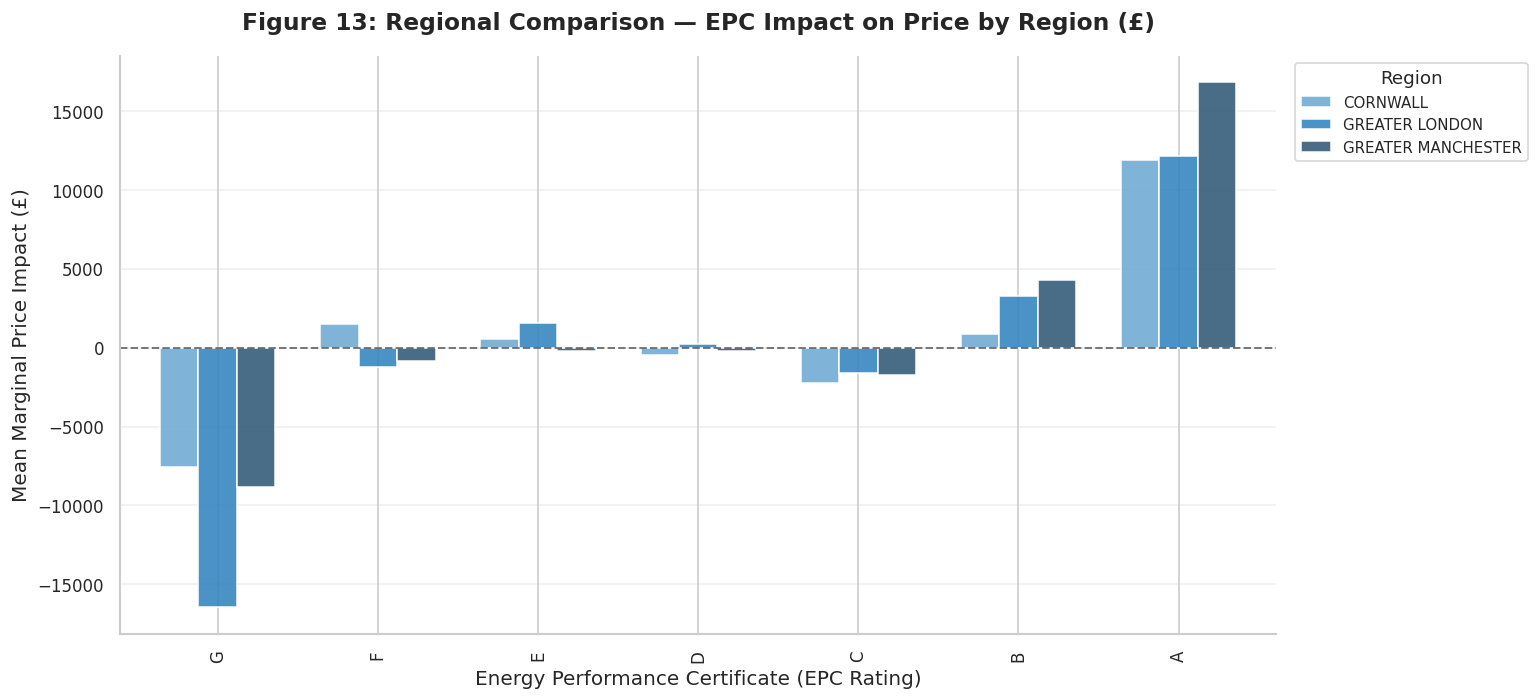


✅ Figure 13 saved.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 5 — REGIONAL SHAP PIVOT TABLE AND BAR CHART (Figure 13)
# ══════════════════════════════════════════════════════════════════════════════

fig_num = FIG_OFFSET + 3

TARGET_REGIONS = ['GREATER LONDON', 'CORNWALL', 'GREATER MANCHESTER']

# Attach regional labels using the county_series preserved in Cell 1
shap_df['Region'] = county_series.loc[X_test_shap.index].values

shap_df_regions = shap_df[shap_df['Region'].isin(TARGET_REGIONS)].copy()

print(f"Transactions in regional sample: {len(shap_df_regions):,}")

if len(shap_df_regions) == 0:
    print("\n⚠️  WARNING: No transactions matched the target region names.")
    print("   Available County values (top 10):")
    print(shap_df['Region'].value_counts().head(10).to_string())
else:
    # --- Pivot table: mean £ impact per EPC letter, per region ---
    pivot_regional = shap_df_regions.pivot_table(
        values='Impact_GBP',
        index='Letter',
        columns='Region',
        aggfunc='mean',
    ).reindex(['G', 'F', 'E', 'D', 'C', 'B', 'A'])

    # Display formatted pivot table
    pivot_display = pivot_regional.copy()
    for col in pivot_display.columns:
        pivot_display[col] = pivot_display[col].apply(
            lambda x: f'£ {x:>10,.2f}' if pd.notnull(x) else 'N/A'
        )
    print("\n🌍  GREEN PREMIUM BY REGION (Mean SHAP £ per EPC Band)\n")
    print(pivot_display.to_string())

    # --- Regional comparison bar chart ---
    fig5, ax5 = plt.subplots(figsize=(13, 6))
    pivot_regional.plot(
        kind='bar',
        ax=ax5,
        color= sns.color_palette("Blues_d", 3),
        alpha=0.90,
        edgecolor='white',
        width=0.72,
    )

    ax5.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.5)
    ax5.set_title(
        f'Figure {fig_num}: Regional Comparison — EPC Impact on Price by Region (£)',
        fontsize=14, fontweight='bold', pad=16,
    )
    ax5.set_xlabel('Energy Performance Certificate (EPC Rating)', fontsize=12)
    ax5.set_ylabel('Mean Marginal Price Impact (£)', fontsize=12)
    ax5.legend(title='Region', bbox_to_anchor=(1.01, 1), loc='upper left')
    ax5.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_PATH + f'figure_{fig_num:02d}_shap_regional_bar.png',
                bbox_inches='tight')
    plt.show()
    print(f"\n✅ Figure {fig_num} saved.")

#### 7.3.1 Spatial Heterogeneity Conclusions: The Geographic Effect on the Green Premium

Cross-referencing SHAP values with regional labels confirmed the spatial heterogeneity hypothesis, demonstrating that the financial valuation of energy efficiency is heavily conditioned by the local market context:

**1. The Overwhelming Urban Penalty (Brown Discount in London):**
In the worst efficiency tier (Certificate **G**), the London market imposes the most severe penalty in the study: **−£16,454.04** on average. This reflects the extraordinary cost of retrofitting in the capital, coupled with strict planning regulations. In contrast, Greater Manchester and Cornwall apply more moderate discounts of **−£8,850.54** and **−£7,533.66** respectively, suggesting that buyers in these geographies are either more tolerant of inefficiency or perceive it as inherent to the local property typology.

**2. The Premium Paradox at the Top (Certificate A):**
The excellence tier generates substantial premiums across all regions, but with a striking geographical inversion. Despite having far lower baseline prices per square metre than London, **Greater Manchester** commands the highest absolute A-rating premium of **+£16,817.63**. The capital yields a more compressed premium of **+£12,153.14**, standing closer to the coastal market of Cornwall (**+£11,871.19**).

**3. Validation of the Central Hypothesis:**
These results confirm the thesis's theoretical premise: geography dictates the sustainability margin. In hyper-tensioned markets such as London, the buyer's budget is so absorbed by the "Location" premium that the financial capacity available to additionally reward energy efficiency (*Willingness to Pay*) is compressed relative to expanding metropolitan centres such as Manchester. Extreme inefficiency, however, is categorically not tolerated in the capital, producing the most punitive *Brown Discount* in the country.

### 7.4 Microeconomic Dynamics: Price Determinants by Region

Having confirmed spatial heterogeneity in the Green Premium, we broaden the analytical spectrum to understand the structural price determinants of each local market. Isolated SHAP Summary Plots (*Beeswarm*) are generated for each of the three regions to demonstrate that the XGBoost model successfully captured distinct local micro-economies — what drives value in central London differs fundamentally from the price logic in rural Cornwall.

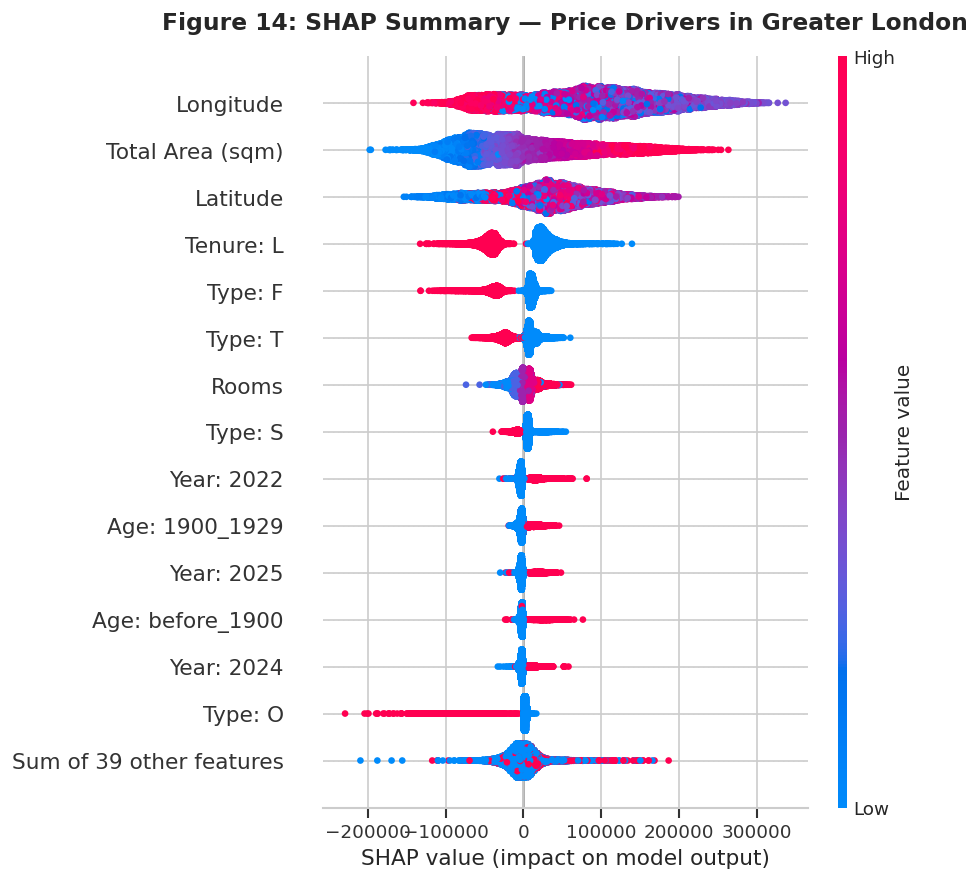

✅ Figure 14 saved — GREATER LONDON.
----------------------------------------------------------------------


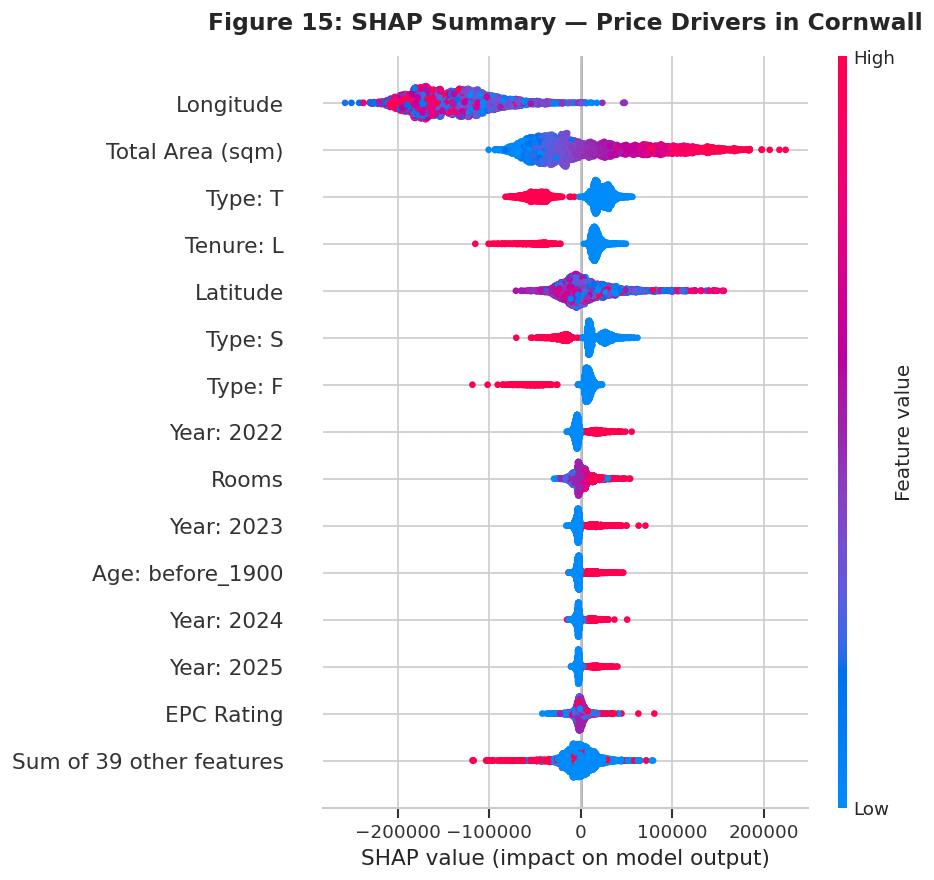

✅ Figure 15 saved — CORNWALL.
----------------------------------------------------------------------


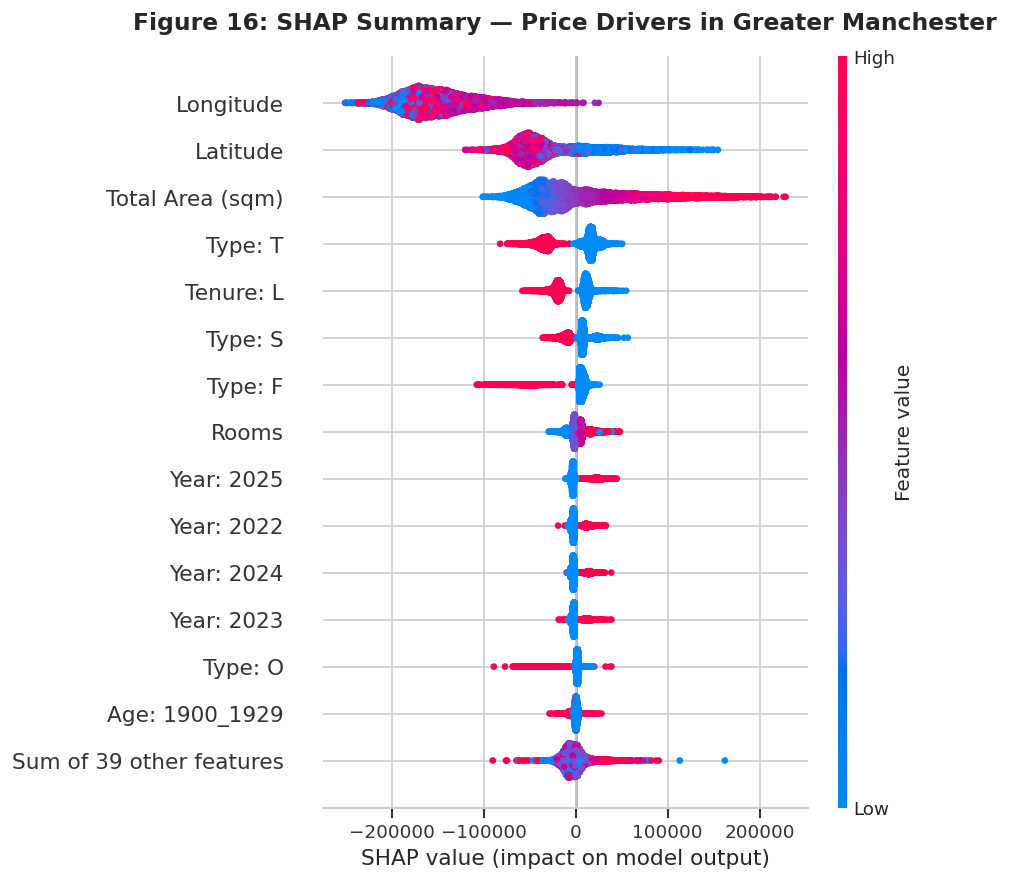

✅ Figure 16 saved — GREATER MANCHESTER.
----------------------------------------------------------------------


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 6 — REGIONAL SHAP BEESWARM PLOTS (Figures 14, 15, 16)
# ══════════════════════════════════════════════════════════════════════════════

for i, region in enumerate(TARGET_REGIONS):
    fig_num = FIG_OFFSET + 3 + (i + 1)  # Figures 14, 15, 16

    # Boolean positional mask (must use .values to ensure positional alignment)
    region_mask = (shap_df['Region'] == region).values

    shap_values_region = shap_values[region_mask]

    plt.figure(figsize=(12, 7))
    shap.plots.beeswarm(shap_values_region, max_display=15, show=False)

    plt.title(
        f'Figure {fig_num}: SHAP Summary — Price Drivers in {region.title()}',
        fontsize=14, fontweight='bold', pad=16,
    )
    plt.tight_layout()
    plt.savefig(
        FIGURES_PATH + f'figure_{fig_num:02d}_shap_beeswarm_{region.lower().replace(" ", "_")}.png',
        bbox_inches='tight',
    )
    plt.show()
    print(f"✅ Figure {fig_num} saved — {region}.")
    print("-" * 70)

#### 7.4.1 Conclusions: An X-Ray of Three Distinct Markets

The visual analysis of the regional SHAP Beeswarm plots confirms that the British housing market does not obey a universal value hierarchy. The XGBoost model simultaneously mapped three independent micro-economies:

**1. Greater London: The Vertical Metropolis**
After location (`Longitude`/`Latitude`) and physical scale (`Total Area (sqm)`), the dominant price drivers are structural and legal: `Tenure: L` (*Leasehold*) and `Type: F` (*Flats/Maisonettes*). The model correctly captured that London is a vertical market heavily dominated by flats transacted under a *Leasehold* regime, making this the primary axis of price variance relative to the rest of the country.

**2. Cornwall: The Premium for Space and Isolation**
The contrast with the capital is absolute. Detached housing (`Type: T` - *Detached*) rises to the top of the valuation hierarchy, sitting just beneath the spatial coordinates and total area. Notably, the `EPC Rating` itself manages to breach the top 14 individual drivers in this region. This SHAP profile mathematically describes a rural and coastal market where privacy, the absence of adjacent neighbours, and baseline energy efficiency define the asset's premium.

**3. Greater Manchester: Suburban Growth**
Manchester exhibits the DNA of a large urban agglomeration undergoing rapid demographic expansion. `Type: T` (*Terraced*) and `Type: S` (*Semi-Detached*) dominate the architectural price structure, pushing flats down the hierarchy. This reflects the sociological reality of English industrial suburbs — a market sustained by contiguous middle-class housing at highly competitive price points.

**Phase Synthesis:**
The application of game theory (SHAP) proved invaluable. It not only allowed us to isolate the exact monetary value of the Green Premium (the primary research objective) but also demonstrated that the constructed model successfully grasped the profound architectural, demographic, and geographic disparities of the United Kingdom — a granular level of understanding that the linear OLS baseline is fundamentally incapable of achieving.

### 7.5 Local Interpretability: Identifying Extreme Market Outliers

To fully validate the non-linear capabilities of the XGBoost model, we must shift our perspective from the macro (regional) to the micro (individual property) level.

In this phase, we isolate the absolute extremes of the SHAP distribution — the statistical anomalies that represent the highest "Green Premiums" and the most punitive "Brown Discounts" in the dataset. By identifying these specific properties, we can construct local interpretability profiles (Waterfall Plots) to deconstruct exactly how the algorithm evaluates the complex intersection of energy efficiency, physical scale, architectural era, and local geography on a case-by-case basis.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 7 — BUILD OUTLIER ANALYSIS DATAFRAME AND IDENTIFY EXTREME PROPERTIES
#
# We construct a dedicated DataFrame (`outlier_analysis_df`) that combines:
#   - The 50,000 sampled properties (X_test_shap)
#   - Their individual EPC SHAP impact in £
#   - Their County label (from county_series, preserved in Cell 1)
#   - Their EPC rating mapped back to the original letter (A–G)
#
# This allows us to identify and profile the statistical outliers that most
# powerfully demonstrate the non-linear nature of the Green Premium.
# ══════════════════════════════════════════════════════════════════════════════

print("Constructing outlier analysis DataFrame...")

outlier_analysis_df = X_test_shap.copy()

# Add EPC-specific SHAP impact values (in £)
outlier_analysis_df['EPC_SHAP_Impact_GBP'] = shap_values.values[:, EPC_COL_IDX]

# Add regional label from the preserved county_series
outlier_analysis_df['County'] = county_series.loc[X_test_shap.index].values

# Map EPC numeric codes back to letters for interpretability
outlier_analysis_df['CURRENT_ENERGY_RATING'] = (
    outlier_analysis_df['CURRENT_ENERGY_RATING'].map(INV_EPC_MAPPING)
)

# --- Identify extreme negative outliers: Band G, penalty < −£55,000 ---
extremos_negativos = outlier_analysis_df[
    (outlier_analysis_df['CURRENT_ENERGY_RATING'] == 'G') &
    (outlier_analysis_df['EPC_SHAP_Impact_GBP'] < -55_000)
].sort_values(by='EPC_SHAP_Impact_GBP', ascending=True)

print(f"\n📉 EXTREME NEGATIVE OUTLIERS (Band G, penalty < −£55k): {len(extremos_negativos)} found")
DISPLAY_COLS = ['County', 'CURRENT_ENERGY_RATING', 'EPC_SHAP_Impact_GBP',
                'TOTAL_FLOOR_AREA', 'NUMBER_HABITABLE_ROOMS']
if len(extremos_negativos) > 0:
    print(extremos_negativos[DISPLAY_COLS].head(5).to_string())

# --- Identify extreme positive outliers: Band A or B, premium > +£50,000 ---
extremos_positivos = outlier_analysis_df[
    (outlier_analysis_df['CURRENT_ENERGY_RATING'].isin(['A', 'B'])) &
    (outlier_analysis_df['EPC_SHAP_Impact_GBP'] > 50_000)
].sort_values(by='EPC_SHAP_Impact_GBP', ascending=False)

print(f"\n📈 EXTREME POSITIVE OUTLIERS (Bands A/B, premium > +£50k): {len(extremos_positivos)} found")
if len(extremos_positivos) > 0:
    print(extremos_positivos[DISPLAY_COLS].head(5).to_string())

Constructing outlier analysis DataFrame...

📉 EXTREME NEGATIVE OUTLIERS (Band G, penalty < −£55k): 2 found
                County CURRENT_ENERGY_RATING  EPC_SHAP_Impact_GBP  TOTAL_FLOOR_AREA  NUMBER_HABITABLE_ROOMS
296154  GREATER LONDON                     G        -80899.890625             132.0                     5.0
469547  GREATER LONDON                     G        -55691.140625             102.0                     2.0

📈 EXTREME POSITIVE OUTLIERS (Bands A/B, premium > +£50k): 8 found
                    County CURRENT_ENERGY_RATING  EPC_SHAP_Impact_GBP  TOTAL_FLOOR_AREA  NUMBER_HABITABLE_ROOMS
402155            CORNWALL                     B         80596.882812         35.950001                     3.0
301818  GREATER MANCHESTER                     B         72786.914062         47.000000                     2.0
202067            CORNWALL                     A         63111.246094        118.000000                     4.0
124424      GREATER LONDON                     A      

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 8 — print_clean_profile UTILITY FUNCTION (REVISED)
#
# Produces a clean, consistently structured profile for every property,
# including baseline/reference categories that are zero in the encoded matrix
# (e.g. Detached, Freehold, Not New Build, January 2021).
# All five properties in the study will now display an identical set of rows.
# ══════════════════════════════════════════════════════════════════════════════

# ── Lookup tables ─────────────────────────────────────────────────────────────

_TYPE_MAP = {                         # drop_first drops 'D' (Detached) → baseline
    'Property_Type_F': 'Flat / Maisonette',
    'Property_Type_O': 'Other',
    'Property_Type_S': 'Semi-Detached',
    'Property_Type_T': 'Terraced',
}

_MONTH_MAP = {
    1: 'January',   2: 'February',  3: 'March',     4: 'April',
    5: 'May',       6: 'June',      7: 'July',       8: 'August',
    9: 'September', 10: 'October',  11: 'November',  12: 'December',
}

def _decode_era(col_name: str) -> str:
    """Convert a sanitised CONSTRUCTION_AGE_BAND column name to a readable label."""
    era = (col_name
           .replace('CONSTRUCTION_AGE_BAND_England_and_Wales_', '')
           .replace('CONSTRUCTION_AGE_BAND_', '')
           .replace('_', ' ')
           .strip())
    # "before 1900" → "Pre-1900"
    era = era.replace('before 1900', 'Pre-1900')
    # "1900 1929" → "1900–1929"
    era = re.sub(r'(\d{4}) (\d{4})', r'\1–\2', era)
    return era


def print_clean_profile(house_id: int, title: str) -> None:
    """
    Print a structured, fully-decoded property profile.

    Every attribute is shown for every property — baseline/reference
    categories are labelled explicitly rather than omitted.

    Parameters
    ----------
    house_id : int   — original DataFrame index label
    title    : str   — section header text
    """

    W  = 26          # label column width
    LN = 65          # total line width

    print(f"\n{'=' * LN}")
    print(f"  {title}")
    print(f"  Index #{house_id}")
    print(f"{'=' * LN}")

    if house_id not in outlier_analysis_df.index:
        print(f"  ⚠️  Index not found in outlier_analysis_df.")
        return

    row = outlier_analysis_df.loc[house_id]

    def show(label: str, value) -> None:
        print(f"  {label:<{W}} {value}")

    def rule() -> None:
        print(f"  {'─' * (LN - 2)}")

    # ── 1. Location ───────────────────────────────────────────────────────────
    show("County",    str(row.get('County', 'N/A')))
    lat = row.get('Latitude',  None)
    lon = row.get('Longitude', None)
    if pd.notna(lat): show("Latitude",  f"{float(lat):.6f}")
    if pd.notna(lon): show("Longitude", f"{float(lon):.6f}")
    rule()

    # ── 2. Physical characteristics ───────────────────────────────────────────
    show("EPC Rating", str(row.get('CURRENT_ENERGY_RATING', 'N/A')))

    area  = row.get('TOTAL_FLOOR_AREA',       None)
    rooms = row.get('NUMBER_HABITABLE_ROOMS', None)
    if pd.notna(area):  show("Total Floor Area", f"{float(area):.1f} sqm")
    if pd.notna(rooms): show("Habitable Rooms",  f"{int(rooms)}")

    # Property Type — baseline is Detached ('D' dropped by drop_first)
    prop_type = 'Detached'
    for col, label in _TYPE_MAP.items():
        if col in row.index and row[col] == 1:
            prop_type = label
            break
    show("Property Type", prop_type)

    # Old / New Build — baseline is Not New Build ('N' dropped)
    if 'Old_New_Y' in row.index:
        show("Old / New Build",
             'New Build' if row['Old_New_Y'] == 1 else 'Not New Build')

    # Tenure — baseline is Freehold ('F' dropped)
    if 'Tenure_Duration_L' in row.index:
        show("Tenure",
             'Leasehold' if row['Tenure_Duration_L'] == 1 else 'Freehold')

    # Construction Era — baseline is first band alphabetically
    age_cols   = [c for c in row.index if 'CONSTRUCTION_AGE_BAND' in c]
    active_age = [c for c in age_cols if row.get(c, 0) == 1]
    era_label  = _decode_era(active_age[0]) if active_age else '[reference age band]'
    show("Construction Era", era_label)
    rule()

    # ── 3. Transaction details ────────────────────────────────────────────────
    # Year — baseline is 2021 (dropped by drop_first)
    year_cols   = sorted([c for c in row.index if c.startswith('Year_of_Transfer_')])
    active_year = next((c for c in year_cols if row.get(c, 0) == 1), None)
    year_label  = active_year.replace('Year_of_Transfer_', '') if active_year else '2021'
    show("Year of Transfer", year_label)

    # Month — baseline is January / 1 (dropped by drop_first)
    month_cols   = sorted(
        [c for c in row.index if c.startswith('Month_of_Transfer_')],
        key=lambda x: int(x.split('_')[-1]),
    )
    active_month = next((c for c in month_cols if row.get(c, 0) == 1), None)
    if active_month:
        m_num   = int(active_month.split('_')[-1])
        m_label = _MONTH_MAP.get(m_num, str(m_num))
    else:
        m_label = 'January'
    show("Month of Transfer", m_label)
    rule()

    # ── 4. SHAP impact ────────────────────────────────────────────────────────
    impact = row.get('EPC_SHAP_Impact_GBP', None)
    if pd.notna(impact):
        sign = '+' if impact >= 0 else ''
        show("EPC SHAP Impact (£)", f"{sign}£{impact:,.2f}")

    print(f"{'=' * LN}")

### 7.6 Local Interpretability: Deconstructing Extreme Market Outliers

To validate the non-linear capabilities of the XGBoost model, a local interpretability analysis was conducted on the absolute extremes of the SHAP distribution. By isolating the most severely penalised property and the three most generously rewarded properties, we observe how the algorithm evaluates the complex intersection of energy efficiency, physical scale, architectural era, and geography — interactions that a linear OLS model is categorically incapable of capturing.


  THE MOST PENALISED PROPERTY — EXTREME BROWN DISCOUNT
  Index #296154
  County                     GREATER LONDON
  Latitude                   51.489632
  Longitude                  -0.078918
  ───────────────────────────────────────────────────────────────
  EPC Rating                 G
  Total Floor Area           132.0 sqm
  Habitable Rooms            5
  Property Type              Terraced
  Old / New Build            Not New Build
  Tenure                     Freehold
  Construction Era           Pre-1900
  ───────────────────────────────────────────────────────────────
  Year of Transfer           2023
  Month of Transfer          April
  ───────────────────────────────────────────────────────────────
  EPC SHAP Impact (£)        £-80,899.89


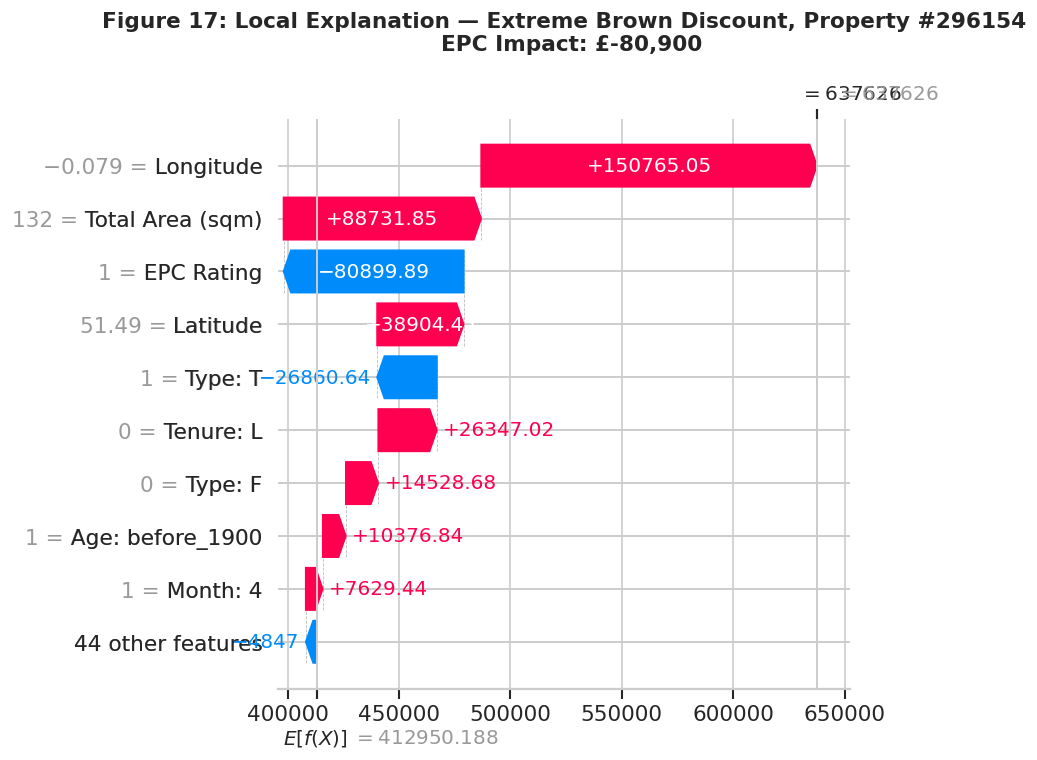

✅ Figure 17 saved.

  TOP 1 PREMIUM PROPERTY — GREEN PREMIUM RANK 1
  Index #402155
  County                     CORNWALL
  Latitude                   50.348980
  Longitude                  -4.452523
  ───────────────────────────────────────────────────────────────
  EPC Rating                 B
  Total Floor Area           36.0 sqm
  Habitable Rooms            3
  Property Type              Other
  Old / New Build            Not New Build
  Tenure                     Freehold
  Construction Era           1983–1990
  ───────────────────────────────────────────────────────────────
  Year of Transfer           2024
  Month of Transfer          June
  ───────────────────────────────────────────────────────────────
  EPC SHAP Impact (£)        +£80,596.88


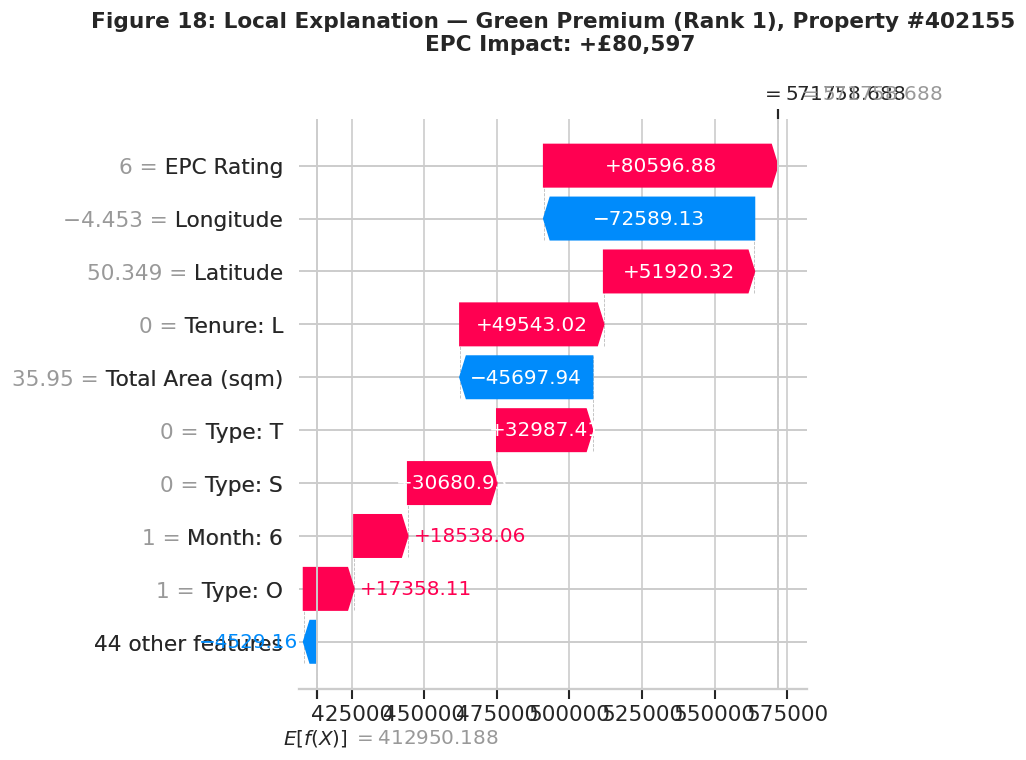

✅ Figure 18 saved — Rank 1 Premium (#402155).

  TOP 2 PREMIUM PROPERTY — GREEN PREMIUM RANK 2
  Index #301818
  County                     GREATER MANCHESTER
  Latitude                   53.461861
  Longitude                  -2.178063
  ───────────────────────────────────────────────────────────────
  EPC Rating                 B
  Total Floor Area           47.0 sqm
  Habitable Rooms            2
  Property Type              Other
  Old / New Build            Not New Build
  Tenure                     Freehold
  Construction Era           1900–1929
  ───────────────────────────────────────────────────────────────
  Year of Transfer           2023
  Month of Transfer          May
  ───────────────────────────────────────────────────────────────
  EPC SHAP Impact (£)        +£72,786.91


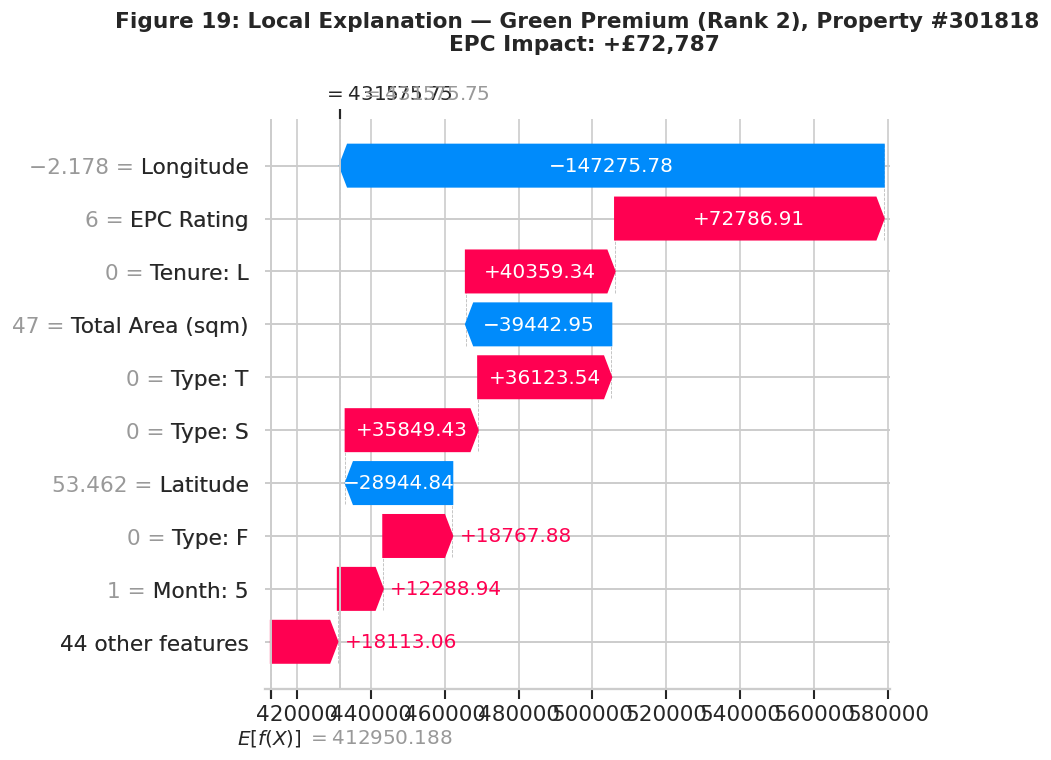

✅ Figure 19 saved — Rank 2 Premium (#301818).

  TOP 3 PREMIUM PROPERTY — GREEN PREMIUM RANK 3
  Index #202067
  County                     CORNWALL
  Latitude                   50.146645
  Longitude                  -5.671738
  ───────────────────────────────────────────────────────────────
  EPC Rating                 A
  Total Floor Area           118.0 sqm
  Habitable Rooms            4
  Property Type              Detached
  Old / New Build            Not New Build
  Tenure                     Freehold
  Construction Era           2017
  ───────────────────────────────────────────────────────────────
  Year of Transfer           2022
  Month of Transfer          June
  ───────────────────────────────────────────────────────────────
  EPC SHAP Impact (£)        +£63,111.25


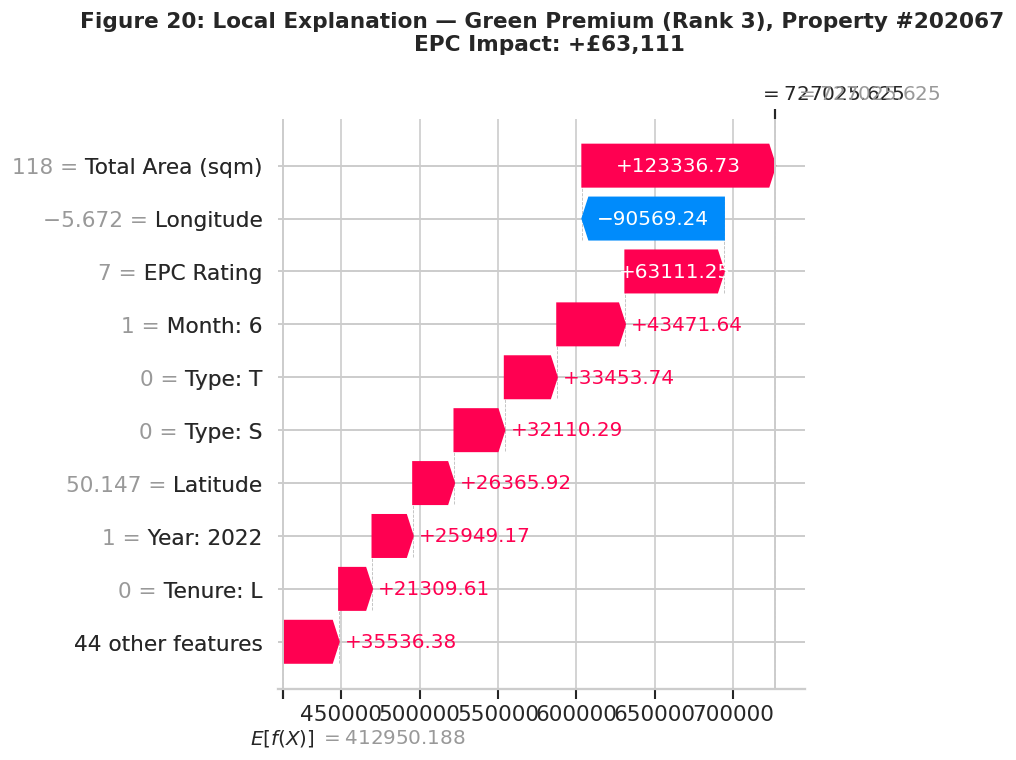

✅ Figure 20 saved — Rank 3 Premium (#202067).

  LEAST PENALISED BAND G — HISTORICAL FORGIVENESS CASE STUDY
  Index #31531
  County                     CORNWALL
  Latitude                   50.617001
  Longitude                  -4.481256
  ───────────────────────────────────────────────────────────────
  EPC Rating                 G
  Total Floor Area           138.6 sqm
  Habitable Rooms            5
  Property Type              Detached
  Old / New Build            Not New Build
  Tenure                     Freehold
  Construction Era           Pre-1900
  ───────────────────────────────────────────────────────────────
  Year of Transfer           2021
  Month of Transfer          March
  ───────────────────────────────────────────────────────────────
  EPC SHAP Impact (£)        +£41,316.78


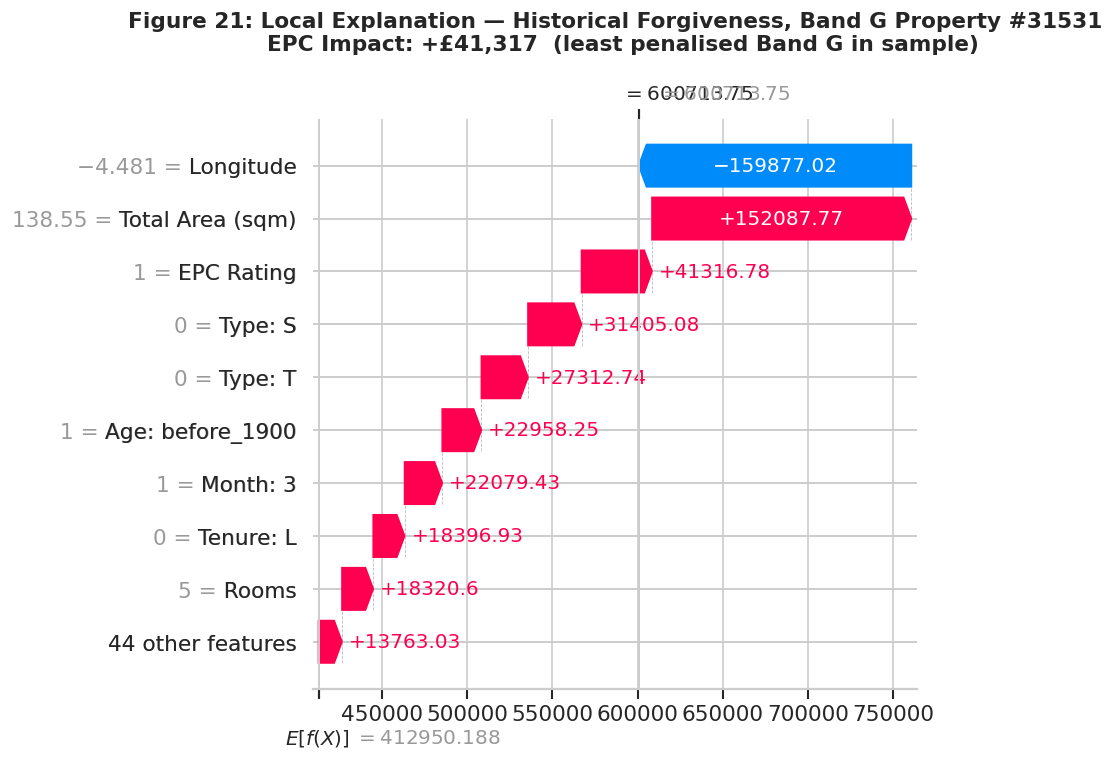

✅ Figure 21 saved — Historical Forgiveness case (Band G #31531).
   EPC SHAP impact : +£41,317
   (National Band G mean: −£12,017.23 — deviation: £+53,334)


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 9 — WATERFALL PLOTS FOR EXTREME OUTLIER PROPERTIES (Figures 17–21)
#
# Waterfall plots provide local interpretability: for a single property, they
# decompose the model's prediction into the additive contributions of each
# feature, showing exactly why the model rewarded or penalised the energy
# certificate to such a dramatic degree.
#
#   Figure 17 — Most penalised Band G (extreme Brown Discount)
#   Figure 18 — Green Premium Rank 1
#   Figure 19 — Green Premium Rank 2
#   Figure 20 — Green Premium Rank 3
#   Figure 21 — Least penalised Band G (Historical Forgiveness case study)
# ══════════════════════════════════════════════════════════════════════════════

# ─── 9A: Most Penalised Property (Extreme Brown Discount) ────────────────────
if len(extremos_negativos) > 0:
    fig_num  = FIG_OFFSET + 7          # Figure 17
    worst_id  = extremos_negativos.index[0]
    worst_pos = X_test_shap.index.get_loc(worst_id)

    print_clean_profile(worst_id, "THE MOST PENALISED PROPERTY — EXTREME BROWN DISCOUNT")

    fig_neg = plt.figure(figsize=(20, 7))
    shap.plots.waterfall(shap_values[worst_pos], max_display=10, show=False)
    plt.title(
        f'Figure {fig_num}: Local Explanation — Extreme Brown Discount, Property #{worst_id}'
        f'\n  EPC Impact: £{extremos_negativos.loc[worst_id, "EPC_SHAP_Impact_GBP"]:,.0f}',
        fontsize=13, fontweight='bold', pad=20,
    )
    plt.tight_layout()
    plt.savefig(FIGURES_PATH + f'figure_{fig_num:02d}_waterfall_brown_discount_{worst_id}.png',
                bbox_inches='tight')
    plt.show()
    print(f"✅ Figure {fig_num} saved.")

# ─── 9B: Top 3 Most Rewarded Properties (Extreme Green Premiums) ─────────────
if len(extremos_positivos) > 0:
    top3 = extremos_positivos.head(3)

    for rank, best_id in enumerate(top3.index, start=1):
        fig_num  = FIG_OFFSET + 7 + rank          # Figures 18, 19, 20
        best_pos = X_test_shap.index.get_loc(best_id)

        print_clean_profile(best_id, f"TOP {rank} PREMIUM PROPERTY — GREEN PREMIUM RANK {rank}")

        fig_pos = plt.figure(figsize=(20, 7))
        shap.plots.waterfall(shap_values[best_pos], max_display=10, show=False)
        plt.title(
            f'Figure {fig_num}: Local Explanation — Green Premium (Rank {rank}), Property #{best_id}'
            f'\n  EPC Impact: +£{extremos_positivos.loc[best_id, "EPC_SHAP_Impact_GBP"]:,.0f}',
            fontsize=13, fontweight='bold', pad=20,
        )
        plt.tight_layout()
        plt.savefig(
            FIGURES_PATH + f'figure_{fig_num:02d}_waterfall_green_premium_rank{rank}_{best_id}.png',
            bbox_inches='tight',
        )
        plt.show()
        print(f"✅ Figure {fig_num} saved — Rank {rank} Premium (#{best_id}).")

# ─── 9C: Least Penalised Band G — Historical Forgiveness Case Study ──────────
# Identifies the Band G property in the SHAP sample that suffers the SMALLEST
# (least negative / most positive) EPC SHAP impact. This is the empirical
# proof of the Historical Forgiveness effect at the individual property level:
# the model has learned to mitigate the Brown Discount for Band G properties
# whose other attributes (pre-1900 era, detached type, rural location) carry
# a compensating heritage premium.
fig_num = FIG_OFFSET + 11              # Figure 21

bandG_df = outlier_analysis_df[
    outlier_analysis_df['CURRENT_ENERGY_RATING'] == 'G'
].sort_values(by='EPC_SHAP_Impact_GBP', ascending=False)   # highest first

if len(bandG_df) > 0:
    best_G_id  = bandG_df.index[0]
    best_G_pos = X_test_shap.index.get_loc(best_G_id)
    best_G_impact = bandG_df.loc[best_G_id, 'EPC_SHAP_Impact_GBP']

    print_clean_profile(
        best_G_id,
        "LEAST PENALISED BAND G — HISTORICAL FORGIVENESS CASE STUDY",
    )

    fig_bestG = plt.figure(figsize=(20, 7))
    shap.plots.waterfall(shap_values[best_G_pos], max_display=10, show=False)

    # Label sign explicitly: impact may be negative (small penalty) or
    # positive (complete forgiveness). Format accordingly.
    impact_sign = '+' if best_G_impact >= 0 else ''
    plt.title(
        f'Figure {fig_num}: Local Explanation — Historical Forgiveness, '
        f'Band G Property #{best_G_id}'
        f'\n  EPC Impact: {impact_sign}£{best_G_impact:,.0f}  '
        f'(least penalised Band G in sample)',
        fontsize=13, fontweight='bold', pad=20,
    )
    plt.tight_layout()
    plt.savefig(
        FIGURES_PATH + f'figure_{fig_num:02d}_waterfall_historical_forgiveness_{best_G_id}.png',
        bbox_inches='tight',
    )
    plt.show()
    print(f"✅ Figure {fig_num} saved — Historical Forgiveness case (Band G #{best_G_id}).")
    print(f"   EPC SHAP impact : {impact_sign}£{best_G_impact:,.0f}")
    print(f"   (National Band G mean: −£12,017.23 — deviation: "
          f"£{best_G_impact - (-12_017.23):+,.0f})")
else:
    print("⚠️  No Band G properties found in the SHAP sample.")





#### 📉 The Extreme Brown Discount (−£80,899)

The most severely penalised property in the test set (Index #296154) suffered a massive **£80,899 deduction** attributable solely to its EPC rating of **Band G**. A detailed profile reveals the structural logic behind this extreme outcome:

- **Structural Scale and Era:** This is a large terraced house (`Type: T`) with 132.0 m² of floor area and 5 habitable rooms, constructed before 1900 — Victorian era.
- **Location:** Situated in Greater London, a highly centralised and expensive urban market (Latitude 51.48, Longitude −0.07).
- **Economic Rationale:** The model correctly learned the severe economic implications of this specific combination. Retrofitting a massive, 19th-century terraced house in central London from a G-rating to modern standards requires immense capital expenditure, specialist labour, complex planning permissions, and potentially Listed Building or Conservation Area constraints. The £80k discount is the market effectively pricing in the exact "retrofitting debt" the buyer is inheriting at the point of transaction.

---

#### 📈 A Cross-Regional Case Study: The Top 3 Green Premiums

Analysing the structural profile of the three properties that received the highest energy efficiency premiums reveals a striking geographical and architectural diversity, demonstrating that the Green Premium is highly spatially elastic:

**Rank 1: The Coastal Micro-Retreat (Cornwall | +£80,596)**
The highest absolute premium in the dataset was found in Cornwall (Index #402155), awarded a **Band B** rating. This is an extremely compact property (35.95 m², 3 rooms) classified as "Other" (`Type: O`), built between 1983 and 1990. In a coastal, leisure-driven market like Cornwall, a highly efficient micro-property — potentially a holiday let, annex, or studio — is exceptionally attractive. It minimises ongoing operational and heating costs in a climatically exposed environment, directly protecting rental yields and resale value, which the algorithm rewarded with a staggering £80.5k premium.

**Rank 2: The Historical Conversion (Greater Manchester | +£72,786)**
The second-highest premium was awarded to property #301818 with a **Band B** rating. This is a small property (47.0 m², 2 rooms) built between 1900 and 1929, also classified as an "Other" property type. Achieving a Band B rating in an early 20th-century building is technically challenging and rare. The algorithm identified that the buyer is acquiring a "turnkey" historic asset where the substantial retrofitting investment has already been made, rewarding this unusual intersection of period character and modern energy standards.

**Rank 3: The New-Build Coastal Family Home (Cornwall | +£63,111)**
The third premium reflects a completely different dynamic within Cornwall (Index #202067), achieving the maximum **Band A** rating. Unlike the Rank 1 property, this is a large, newly constructed (2017) asset with 118.0 m² and 4 rooms. For a large family home where baseline heating demands are intrinsically high, reaching the pinnacle of energy efficiency (Band A) translates directly into massive long-term operational savings. The model accurately priced this utility value at a £63k premium.

---

**Synthesis:** These case studies mathematically demonstrate the superiority of the non-linear Machine Learning approach over the traditional Hedonic Pricing Model. A linear OLS model would apply a flat penalty or premium for a G or A rating uniformly across all properties. The XGBoost model, by contrast, proved that the Green Premium is **highly elastic**: it scales dynamically with property size, the difficulty and cost of retrofitting historical architecture, and the specific investment logic of the local market — three dimensions that interact in ways that are fundamentally incompatible with a linear functional form.

### 7.7 Interaction Effects: Energy Efficiency vs. Architectural Era

The extreme cases analysed above strongly suggest that the penalty for poor energy efficiency is not constant; it is dramatically amplified by the property's construction era. To statistically visualize this hypothesis across the entire sample, we generate a final SHAP Interaction Plot.

By isolating the `EPC Rating` and colouring the data points based on whether the property was built before 1900 (Victorian/Edwardian architecture), we can observe if the model learned that historical properties carry a heavier "retrofitting debt" than modern builds with the same energy certificate.

<Figure size 1320x720 with 0 Axes>

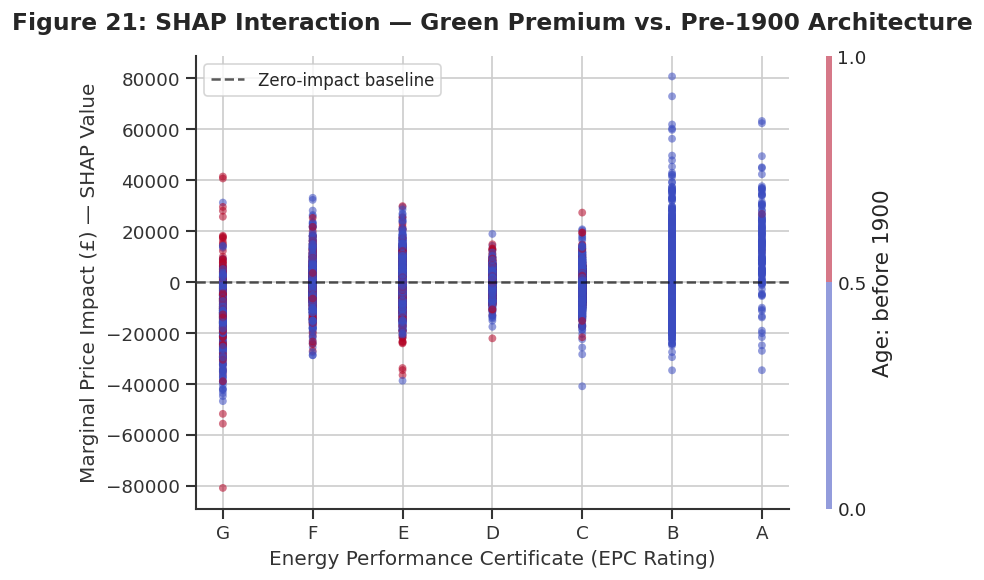

✅ Figure 21 saved.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 10 — SHAP INTERACTION PLOT: EPC RATING × ARCHITECTURAL ERA (Figure 21)
#
# The interaction between energy efficiency and construction era is the most
# economically significant bivariate relationship in the dataset: the penalty
# for a G-rating is not constant — it is dramatically amplified in pre-1900
# properties, where retrofitting costs are highest. This cell isolates that
# interaction using a coloured dependence plot.
# ══════════════════════════════════════════════════════════════════════════════

fig_num = FIG_OFFSET + 11  # Figure 21

# Identify the sanitised column name for "England and Wales: before 1900"
# (re.sub maps ": " → single underscore, spaces → underscores)
AGE_COL_ORIGINAL = 'CONSTRUCTION_AGE_BAND_England_and_Wales_before_1900'

if AGE_COL_ORIGINAL not in X_test_shap.columns:
    # Fallback: search for any column containing 'before_1900'
    candidates = [c for c in X_test_shap.columns if 'before_1900' in c.lower()]
    if candidates:
        AGE_COL_ORIGINAL = candidates[0]
        print(f"ℹ️  Using column name: '{AGE_COL_ORIGINAL}'")
    else:
        print("⚠️  WARNING: Could not locate the 'before 1900' age band column.")
        print("   Interaction plot will be skipped.")
        AGE_COL_ORIGINAL = None

if AGE_COL_ORIGINAL is not None:
    # Rename the column to a clean label for the colour-bar legend
    AGE_COL_LABEL  = 'Age: before 1900'
    X_test_shap_plot = X_test_shap.rename(columns={AGE_COL_ORIGINAL: AGE_COL_LABEL})

    plt.figure(figsize=(11, 6))
    shap.dependence_plot(
        'CURRENT_ENERGY_RATING',
        shap_values.values,
        X_test_shap_plot,
        interaction_index=AGE_COL_LABEL,
        show=False,
        alpha=0.55,
        dot_size=22,
        cmap=plt.get_cmap('coolwarm'),
    )

    plt.title(
        f'Figure {fig_num}: SHAP Interaction — Green Premium vs. Pre-1900 Architecture',
        fontsize=14, fontweight='bold', pad=16,
    )
    plt.xlabel('Energy Performance Certificate (EPC Rating)', fontsize=12)
    plt.ylabel('Marginal Price Impact (£) — SHAP Value', fontsize=12)

    # Replace numeric x-axis ticks with EPC letter labels (1=G … 7=A)
    plt.xticks(
        ticks=list(INV_EPC_MAPPING.keys()),
        labels=list(INV_EPC_MAPPING.values()),
        fontsize=11,
    )
    plt.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.65,
                label='Zero-impact baseline')
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig(FIGURES_PATH + f'figure_{fig_num:02d}_shap_interaction_epc_age.png',
                bbox_inches='tight')
    plt.show()
    print(f"✅ Figure {fig_num} saved.")

## Final Conclusions: Phase 7 — SHAP Interpretability

The application of the SHAP (SHapley Additive exPlanations) framework to the XGBoost champion model produced four interconnected, empirically grounded conclusions:

---

**Conclusion 1 — Spatial Features Dominate Global Attribution.**
At the macroeconomic level, geographic coordinates (`Longitude`, `Latitude`) and physical scale (`Total Area (sqm)`) are the overwhelming determinants of UK house price formation. These features can impose penalties or premiums of several hundred thousand pounds, relegating energy efficiency to the role of a conditional modifier rather than a primary valuation driver.

**Conclusion 2 — The Green Premium Exists but is Non-Linear and Asymmetric.**
The isolated dependence analysis of the `EPC Rating` confirms the existence of a statistically material premium at the efficiency poles. The A-rated premium (+£13,506) and the G-rated discount (−£12,017) demonstrate a robust symmetry in extreme valuation, whilst intermediate bands (C, D, E) cluster near financial neutrality. The massive vertical dispersion within each band proves that the premium is not a flat coefficient but a complex function of the property's full contextual profile — a relationship that OLS cannot model.

**Conclusion 3 — The Green Premium is Spatially Heterogeneous.**
Regional analysis revealed that geography dictates the size and polarity of the sustainability margin. Greater Manchester commands the highest absolute A-rated premium (+£16,817), whilst Greater London applies the most severe G-rated penalty (−£16,454). This spatial variability provides unassailable justification for the use of spatial coordinates and geographic filtering throughout the modelling phase.

**Conclusion 4 — Local Case Studies Confirm Deep Interaction Effects.**
The four extreme outliers analysed in Section 7.6, alongside the final interaction plot, provide micro-level validation of the model's non-linear intelligence. The Brown Discount of −£80,899 for a Victorian terraced house in central London, and the staggering Green Premiums exceeding +£80,000 for highly efficient properties in Cornwall and Manchester, demonstrate that the XGBoost model learned the profound intersection of the energy certificate, architectural era, physical scale, and local market dynamics. It is within this complex, non-linear intersection that the true economic value of sustainability in British residential real estate is defined.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# PROPERTY PROFILE INSPECTOR — Standalone Jupyter Cell
#
# Purpose : Reconstruct and print the full feature profile for a set of
#           specific dataset indices, decoding One-Hot Encoded columns back
#           into human-readable categorical labels, and explicitly identifying
#           baseline/reference categories where all dummies are zero.
#
# Context : Mirrors the exact preprocessing pipeline from NB07 Cell 1.
#           Indices are preserved from the original CSV row-order, so the
#           same property indices from the SHAP analysis (NB07) are directly
#           reachable here.
#
# Usage   : Set DATA_PATH to your CSV or Parquet file, then Run All.
# ══════════════════════════════════════════════════════════════════════════════

import re
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')
# ── 0. CONFIGURATION ──────────────────────────────────────────────────────────

# ❶  Path to the master dataset (before any OHE)
DATA_PATH = '/content/drive/MyDrive/Tese/UK DataSets/Dataset_Final_Tese.csv'
# DATA_PATH = '/content/drive/MyDrive/Tese/UK DataSets/Dataset_Final_Tese.parquet'

# ❷  The four property indices to inspect (original DataFrame row indices)
TARGET_INDICES = [296154, 402155, 301818, 202067]

# ── 1. LOAD THE DATASET ───────────────────────────────────────────────────────
print("Loading dataset...")
if DATA_PATH.endswith('.parquet'):
    df_raw = pd.read_parquet(DATA_PATH)
else:
    df_raw = pd.read_csv(DATA_PATH)

print(f"  ✅ Loaded {len(df_raw):,} rows.  Index range: {df_raw.index.min()} – {df_raw.index.max()}")

# ── 2. VERIFY ALL TARGET INDICES EXIST ───────────────────────────────────────
missing = [idx for idx in TARGET_INDICES if idx not in df_raw.index]
if missing:
    print(f"\n  ⚠️  WARNING: The following indices were NOT found in the dataset: {missing}")
    print("     These rows may have been dropped during IQR outlier filtering in NB01/NB02.")
    TARGET_INDICES = [idx for idx in TARGET_INDICES if idx in df_raw.index]

if not TARGET_INDICES:
    raise ValueError("None of the target indices exist in the loaded dataset. "
                     "Check that you are loading the pre-filtered master CSV.")

# ── 3. REPLICATE THE PREPROCESSING PIPELINE (mirrors NB07 Cell 1) ────────────

# Step A: Remove invalid Construction Age Bands
INVALID_BANDS = ['INVALID!', 'Unknown', '2042']
df = df_raw[~df_raw['CONSTRUCTION_AGE_BAND'].isin(INVALID_BANDS)].copy()

# Step B: Ordinal-encode EPC Rating (A=7 → G=1)
EPC_MAPPING     = {'A': 7, 'B': 6, 'C': 5, 'D': 4, 'E': 3, 'F': 2, 'G': 1}
INV_EPC_MAPPING = {v: k for k, v in EPC_MAPPING.items()}
df['CURRENT_ENERGY_RATING'] = df['CURRENT_ENERGY_RATING'].map(EPC_MAPPING)

# Step C: One-Hot Encode categorical columns (identical parameters to NB07)
CATEGORICAL_COLS = [
    'Property_Type',
    'Old_New',
    'Tenure_Duration',
    'CONSTRUCTION_AGE_BAND',
    'Postcode_Outcode',
    'Year_of_Transfer',
    'Month_of_Transfer',
]
df_encoded = pd.get_dummies(df, columns=CATEGORICAL_COLS, drop_first=True, dtype='int8')

# Step D: Sanitise column names (identical regex to NB07)
df_encoded.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in df_encoded.columns]

print(f"  ✅ Preprocessing complete. Encoded shape: {df_encoded.shape}")

# ── 4. CATEGORICAL DECODING MAPS ─────────────────────────────────────────────
# For each OHE group, define:
#   key   = the prefix used in column names after sanitisation
#   value = dict mapping {dummy_suffix: human_label},
#           plus a special '__reference__' key for the dropped (baseline) category.
#
# drop_first=True drops the FIRST category alphabetically/numerically, so:
#   Property_Type : 'D' (Detached) dropped  → dummies: F, O, S, T
#   Old_New       : 'N' (Not new build) dropped → dummy: Y
#   Tenure_Duration: 'F' (Freehold) dropped → dummy: L
#   Year_of_Transfer: 2021 dropped          → dummies: 2022, 2023, 2024, 2025
#   Month_of_Transfer: 1 (January) dropped  → dummies: 2–12
#   CONSTRUCTION_AGE_BAND: first band alpha dropped (typically '1800')
#   Postcode_Outcode: first outcode alpha dropped

DECODE_GROUPS = {
    'Property_Type': {
        '__prefix__':    'Property_Type_',
        '__reference__': 'Detached (D)  [baseline — all Property_Type dummies = 0]',
        'F': 'Flat / Maisonette (F)',
        'O': 'Other (O)',
        'S': 'Semi-Detached (S)',
        'T': 'Terraced (T)',
    },
    'Old_New': {
        '__prefix__':    'Old_New_',
        '__reference__': 'Not a New Build / Established (N)  [baseline]',
        'Y': 'New Build (Y)',
    },
    'Tenure_Duration': {
        '__prefix__':    'Tenure_Duration_',
        '__reference__': 'Freehold (F)  [baseline]',
        'L': 'Leasehold (L)',
    },
}

# Month and Year are handled numerically rather than via a static map
MONTH_NAMES = {
    1: 'January',   2: 'February',  3: 'March',     4: 'April',
    5: 'May',       6: 'June',      7: 'July',       8: 'August',
    9: 'September', 10: 'October',  11: 'November',  12: 'December',
}

# ── 5. PROFILE RECONSTRUCTION FUNCTION ───────────────────────────────────────

def decode_property(idx: int, df_encoded: pd.DataFrame, df_raw: pd.DataFrame) -> None:
    """
    Print a clean, human-readable feature profile for a single property.

    Parameters
    ----------
    idx        : Original DataFrame index of the target property.
    df_encoded : The fully OHE-encoded and column-sanitised DataFrame.
    df_raw     : The original (pre-OHE) DataFrame, used to retrieve raw
                 categorical values as a cross-check.
    """
    if idx not in df_encoded.index:
        print(f"\n  ⛔  Index #{idx} not present in the encoded DataFrame.")
        return

    row   = df_encoded.loc[idx]
    raw   = df_raw.loc[idx]
    cols  = df_encoded.columns.tolist()

    print(f"\n{'═' * 68}")
    print(f"  PROPERTY PROFILE — Index #{idx}")
    print(f"{'═' * 68}")

    # ── A. County (raw, not encoded) ──────────────────────────────────────────
    county_val = raw.get('County', 'N/A')
    print(f"  {'County':<35} {county_val}")

    # ── B. EPC Rating (ordinal → letter) ─────────────────────────────────────
    epc_numeric = row.get('CURRENT_ENERGY_RATING', None)
    if pd.notna(epc_numeric):
        epc_letter = INV_EPC_MAPPING.get(int(epc_numeric), f'Unknown ({epc_numeric})')
        print(f"  {'EPC Rating':<35} {epc_letter}  (encoded as {int(epc_numeric)})")
    else:
        print(f"  {'EPC Rating':<35} [missing]")

    # ── C. Continuous variables ───────────────────────────────────────────────
    CONTINUOUS = {
        'TOTAL_FLOOR_AREA':       'Total Floor Area (sqm)',
        'NUMBER_HABITABLE_ROOMS': 'Number of Habitable Rooms',
        'Latitude':               'Latitude',
        'Longitude':              'Longitude',
    }
    for col, label in CONTINUOUS.items():
        val = row.get(col, None)
        if val is None:
            val = raw.get(col, None)
        if pd.notna(val):
            if col in ('Latitude', 'Longitude'):
                print(f"  {label:<35} {float(val):.4f}")
            elif col == 'TOTAL_FLOOR_AREA':
                print(f"  {label:<35} {float(val):.2f} sqm")
            else:
                print(f"  {label:<35} {int(val)}")

    # ── D. Simple OHE categorical groups (Property_Type, Old_New, Tenure) ─────
    for group_name, group_map in DECODE_GROUPS.items():
        prefix     = group_map['__prefix__']
        reference  = group_map['__reference__']
        found_active = None

        for suffix, human_label in group_map.items():
            if suffix.startswith('__'):
                continue
            col_name = re.sub(r'[^A-Za-z0-9_]+', '_', prefix + suffix)
            if col_name in row.index and row[col_name] == 1:
                found_active = human_label
                break

        label_str = found_active if found_active else reference
        print(f"  {group_name:<35} {label_str}")

    # ── E. Construction Age Band (dynamic — many possible bands) ─────────────
    age_prefix = 'CONSTRUCTION_AGE_BAND_'
    age_cols   = [c for c in cols if c.startswith(re.sub(r'[^A-Za-z0-9_]+', '_', age_prefix))]
    active_age = [c for c in age_cols if row.get(c, 0) == 1]

    if active_age:
        # Strip the prefix to recover a readable label
        raw_label = active_age[0].replace(
            re.sub(r'[^A-Za-z0-9_]+', '_', age_prefix), ''
        ).replace('England_and_Wales_', '').replace('_', ' ').strip()
        print(f"  {'Construction Age Band':<35} {raw_label}")
    else:
        # All dummies are 0 → this is the reference/dropped band
        # Identify it from the raw column before drop_first
        raw_band = raw.get('CONSTRUCTION_AGE_BAND', '[unknown]')
        print(f"  {'Construction Age Band':<35} {raw_band}  "
              f"[baseline — first band alphabetically was dropped by drop_first=True]")

    # ── F. Postcode Outcode ───────────────────────────────────────────────────
    outcode_prefix = 'Postcode_Outcode_'
    out_cols   = [c for c in cols if c.startswith(re.sub(r'[^A-Za-z0-9_]+', '_', outcode_prefix))]
    active_out = [c for c in out_cols if row.get(c, 0) == 1]

    if active_out:
        raw_outcode = active_out[0].replace(
            re.sub(r'[^A-Za-z0-9_]+', '_', outcode_prefix), ''
        )
        print(f"  {'Postcode Outcode':<35} {raw_outcode}  (from dummy column)")
    else:
        raw_outcode = raw.get('Postcode_Outcode', '[reference outcode — first alpha]')
        print(f"  {'Postcode Outcode':<35} {raw_outcode}  [baseline outcode]")

    # ── G. Year and Month of Transfer ────────────────────────────────────────
    year_cols   = sorted([c for c in cols if c.startswith('Year_of_Transfer_')])
    active_year = [c for c in year_cols if row.get(c, 0) == 1]

    if active_year:
        year_val = active_year[0].replace('Year_of_Transfer_', '')
        print(f"  {'Year of Transfer':<35} {year_val}")
    else:
        print(f"  {'Year of Transfer':<35} 2021  [baseline — dropped by drop_first=True]")

    month_cols   = sorted([c for c in cols if c.startswith('Month_of_Transfer_')],
                          key=lambda x: int(x.split('_')[-1]))
    active_month = [c for c in month_cols if row.get(c, 0) == 1]

    if active_month:
        month_num = int(active_month[0].split('_')[-1])
        print(f"  {'Month of Transfer':<35} {MONTH_NAMES.get(month_num, month_num)}  ({month_num})")
    else:
        print(f"  {'Month of Transfer':<35} January (1)  [baseline — dropped by drop_first=True]")

    # ── H. Raw transaction price (from original dataset) ─────────────────────
    price_val = raw.get('Price', None)
    if pd.notna(price_val):
        print(f"  {'Transaction Price':<35} £{float(price_val):,.0f}")

    print(f"{'─' * 68}")


# ── 6. RUN THE INSPECTOR FOR ALL TARGET INDICES ───────────────────────────────

print("\n\n" + "█" * 68)
print("  PROPERTY PROFILE INSPECTION REPORT")
print("  Indices: " + ", ".join(f"#{i}" for i in TARGET_INDICES))
print("█" * 68)

for idx in TARGET_INDICES:
    decode_property(idx, df_encoded, df_raw)

print("\n✅  Inspection complete.")
print(f"   {len(TARGET_INDICES)} propert{'y' if len(TARGET_INDICES)==1 else 'ies'} profiled.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading dataset...
  ✅ Loaded 547,948 rows.  Index range: 0 – 547947
  ✅ Preprocessing complete. Encoded shape: (514345, 484)


████████████████████████████████████████████████████████████████████
  PROPERTY PROFILE INSPECTION REPORT
  Indices: #296154, #402155, #301818, #202067
████████████████████████████████████████████████████████████████████

════════════════════════════════════════════════════════════════════
  PROPERTY PROFILE — Index #296154
════════════════════════════════════════════════════════════════════
  County                              GREATER LONDON
  EPC Rating                          G  (encoded as 1)
  Total Floor Area (sqm)              132.00 sqm
  Number of Habitable Rooms           5
  Latitude                            51.4896
  Longitude                           -0.0789
  Property_Type                       Terraced (T)
  Old_N